#**1. Logistic Regression**
Deklarasikan dependency dan nyakakan CPU


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# make_classification : Module yang dapat digunakan untuk menghasilkan data random untuk klasifikasi n-class
# train_test_split : Module yang dapat digunakan untuk membagi dataset ke dalam dua bagian (train & test)
# StandardScaler : Module yang dapat digunakan untuk normalisasi dengan z = (x - mean) / standard_dev
# accuracy_score, precision_score, recall_score, confusion_matrix : Module untuk mengukur kualitas dari model
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.linear_model import LogisticRegression

# Pengaturan untuk menentukan device komputasi yang akan digunakan
device = "cpu"
print(f"Using device: {device}")

Using device: cpu


#1.1. Data Generation
### Membuat 200 Sample data random dengan 2 feature dan 2 class dan melakukan plotting pada data tersebut

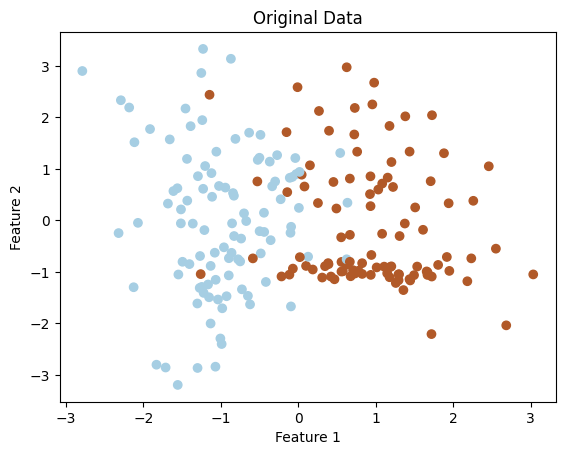

In [3]:
# Pembuatan data sintesis
X, y = make_classification(n_samples=200, n_features=2, n_classes=2, n_clusters_per_class=2,
n_informative=2, n_redundant=0, random_state=10)

# Melakukan visualize data
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired, marker='o')
plt.title("Original Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# 1.2 Data Preparation
### Membagi data menjadi testing dan data training
### Melakukan Normalisasi pada data
### Memastikan tipe data adalah float 32
### Melakukan plotting data

Sample sebaran nilai sebelum normalisasi dari X_train
[[ 1.72203255 -1.09049967]
 [ 1.29996826 -1.04787414]
 [ 1.15339485  0.83008524]
 [-1.65834816  1.57180487]
 [ 0.07969126  0.65708154]
 [ 0.25369387  0.3365649 ]
 [-0.09472556 -1.67043041]
 [ 0.49183849  0.23034876]
 [ 0.55721369 -0.80733758]
 [-1.36114309 -0.06293801]]

Sample sebaran nilai setelah normalisasi dari X_train
[[ 1.46400241 -0.7940774 ]
 [ 1.11394115 -0.76252513]
 [ 0.99237277  0.62757802]
 [-1.33969441  1.17661375]
 [ 0.10184014  0.49951721]
 [ 0.24615837  0.26226437]
 [-0.04282163 -1.22335375]
 [ 0.44367615  0.18364106]
 [ 0.49789853 -0.58447515]
 [-1.09319172 -0.03345568]]
Ukuran array X_train :  (140, 2)
Ukuran array y_train :  (140, 1)
Ukuran array X_test :  (60, 2)
Ukuran array y_test :  (60, 1)


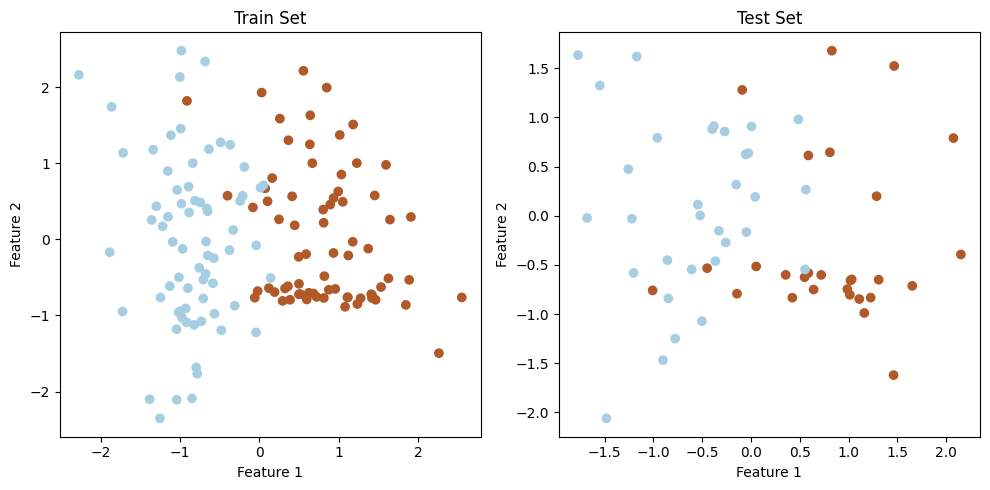

In [5]:
# Membagi kumpulan data ke dalam data training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Sample sebaran nilai sebelum normalisasi dari X_train")
print(X_train[0:10,:])
# Normalisasi atau standarisasi dari nilai feature
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("\nSample sebaran nilai setelah normalisasi dari X_train")
print(X_train[0:10,:])

# Memastikan tipe data adalah float32 dan melakukan reshape pada y
X_train_np = X_train.astype(np.float32)
y_train_np = y_train.reshape(-1, 1).astype(np.float32)
X_test_np = X_test.astype(np.float32)
y_test_np = y_test.reshape(-1, 1).astype(np.float32)
print("Ukuran array X_train : ", X_train_np.shape)
print("Ukuran array y_train : ", y_train_np.shape)
print("Ukuran array X_test : ", X_test_np.shape)
print("Ukuran array y_test : ", y_test_np.shape)

# Melakukan visualisasi data pasca proses normalisasi/standarisasi
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.Paired, marker='o')
plt.title("Train Set")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.subplot(1, 2, 2)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.Paired, marker='o')
plt.title("Test Set")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()

#1.3 Melakukan definisi fungsi utils(Sigmoid dan Forward Bias)
### 1. Fungsi Sigmoid digunakan sebagai fungsi aktivasi dari model Logistic yang digunakan
### 2. Fungsi forward didefinisikan menggunakan dot product dari input dan weight + bias, dan memasukkan output ke sigmoid
### 3. Fungsi criterion memberi loss function(CBE)
###
###Architecture kemudian disiapkan untuk membuat top level

In [6]:
# Fungsi aktivasi Sigmoid
def sigmoid(x):
  return 1 / (1 + np.exp(-x))
# Fungsi Forward Propagation (Linear + Sigmoid)
def forward(X, weights, bias):
  # z = XW + b
  hasil_layer = np.dot(X, weights) + bias
  hasil_logistik = sigmoid(hasil_layer)
  return hasil_logistik

# Implementasi Binary Cross Entropy Loss
def criterion(y_pred, y_true):
  # Menambahkan epsilon kecil agar tidak terjadi log(0)
  epsilon = 1e-15
  y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
  loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
  return loss

In [7]:
# Menyiapkan arsitektur Logistic Regression manual
input_size = X_train.shape[1]
output_size = 1
# Inisialisasi parameter (Weights & Bias) secara random
np.random.seed(42) # Agar hasil konsisten
weights = np.random.randn(input_size, output_size).astype(np.float32) * 0.01
bias = np.zeros((1, output_size)).astype(np.float32)
# Hyperparameters
learning_rate = 0.01
momentum = 0.9 # Untuk implementasi SGD
print(f"Model diinisialisasi dengan weights shape: {weights.shape} dan bias shape: {bias.shape}")


Model diinisialisasi dengan weights shape: (2, 1) dan bias shape: (1, 1)


#1.4 Training Process
### Main code dari Logistic regression, seperti linear regression, per epoch dilakukan inference terlebih dahulu, weight dan bias selanjutnya dilatih dari CBE loss. Terakhir per epoch diappend parameter performansi dan per 10 epoch diprint parameter performance tersebut.

In [8]:
# Pendefinisian beberapa variabel untuk training loop
train_losses, test_losses, train_accuracies, test_accuracies = [], [], [], []
num_epochs = 1000
threshold = 0.5 # Digunakan untuk konversi output ke binary
# Data sudah dalam bentuk NumPy array dari tahap sebelumnya
# X_train_np, y_train_np, X_test_np, y_test_np

for epoch in range(num_epochs):
  # Forward Pass
  # Menghitung prediksi: y = sigmoid(XW + b)
  y_pred_train = forward(X_train_np, weights, bias)
  # Perhitungan Loss (BCE)
  loss = criterion(y_pred_train, y_train_np)
  # Perhitungan Accuracy
  y_train_binary = (y_pred_train >= threshold).astype(int)
  train_accuracy = accuracy_score(y_train_np, y_train_binary)
  # Backpropagation
  # Jumlah sampel
  m = X_train_np.shape[0]
  # Gradien Loss terhadap z (error)
  dz = y_pred_train - y_train_np
  # Gradien terhadap Weights (dW = 1/m * X^T * dz)
  dw = (1 / m) * np.dot(X_train_np.T, dz)
  # Gradien terhadap Bias (db = 1/m * sum(dz))
  db = (1 / m) * np.sum(dz, axis=0, keepdims=True)
  # Update Parameters (Simple SGD)
  weights -= learning_rate * dw
  bias -= learning_rate * db
  # Evaluasi model pada test set
  y_pred_test = forward(X_test_np, weights, bias)
  test_loss = criterion(y_pred_test, y_test_np)
  y_test_binary = (y_pred_test >= threshold).astype(int)
  test_accuracy = accuracy_score(y_test_np, y_test_binary)
  # Memberikan informasi pembaharuan setiap 10 epoch
  if (epoch + 1) % 10 == 0:
    print("Epoch [{}] -> Train Loss: {:.4f}; Test Loss: {:.4f}; Train Acc: {:.2f}%; Test Acc: {:.2f}%"
    .format(epoch + 1, loss, test_loss, train_accuracy * 100, test_accuracy * 100))
  # Store losses and accuracies
  train_losses.append(loss)
  test_losses.append(test_loss)
  train_accuracies.append(train_accuracy)
  test_accuracies.append(test_accuracy)

Epoch [10] -> Train Loss: 0.6757; Test Loss: 0.6775; Train Acc: 94.29%; Test Acc: 85.00%
Epoch [20] -> Train Loss: 0.6594; Test Loss: 0.6645; Train Acc: 94.29%; Test Acc: 83.33%
Epoch [30] -> Train Loss: 0.6439; Test Loss: 0.6521; Train Acc: 94.29%; Test Acc: 83.33%
Epoch [40] -> Train Loss: 0.6291; Test Loss: 0.6403; Train Acc: 94.29%; Test Acc: 83.33%
Epoch [50] -> Train Loss: 0.6150; Test Loss: 0.6292; Train Acc: 94.29%; Test Acc: 83.33%
Epoch [60] -> Train Loss: 0.6016; Test Loss: 0.6187; Train Acc: 94.29%; Test Acc: 83.33%
Epoch [70] -> Train Loss: 0.5888; Test Loss: 0.6087; Train Acc: 94.29%; Test Acc: 83.33%
Epoch [80] -> Train Loss: 0.5767; Test Loss: 0.5992; Train Acc: 94.29%; Test Acc: 83.33%
Epoch [90] -> Train Loss: 0.5650; Test Loss: 0.5902; Train Acc: 94.29%; Test Acc: 83.33%
Epoch [100] -> Train Loss: 0.5540; Test Loss: 0.5816; Train Acc: 94.29%; Test Acc: 83.33%
Epoch [110] -> Train Loss: 0.5434; Test Loss: 0.5735; Train Acc: 94.29%; Test Acc: 83.33%
Epoch [120] -> Trai

# 1.5. Model Evaluation
### Dilakukan perhitungan performa model dengan menggunakan Akurasi(TP+TN/(TP+TN+FP+FN))
### Ploting hasil akurasi dan loss yang disimpan pada stack

Final Evaluation:
Accuracy: 83.33%
Confusion Matrix:
Precision: 0.78125
Recall: 0.8928571428571429


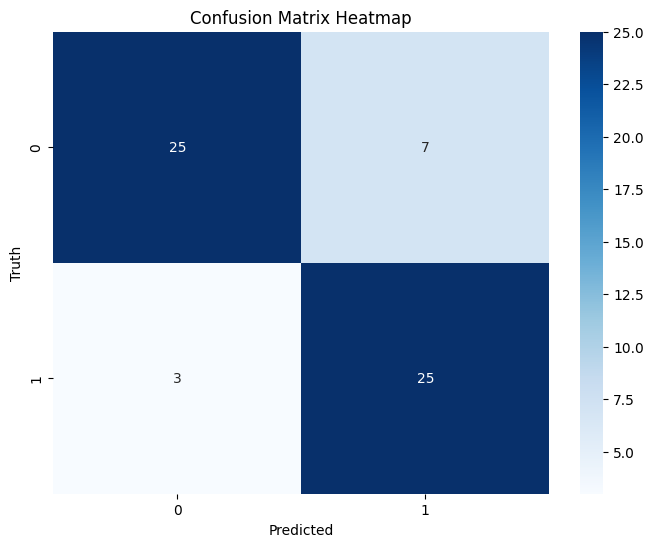

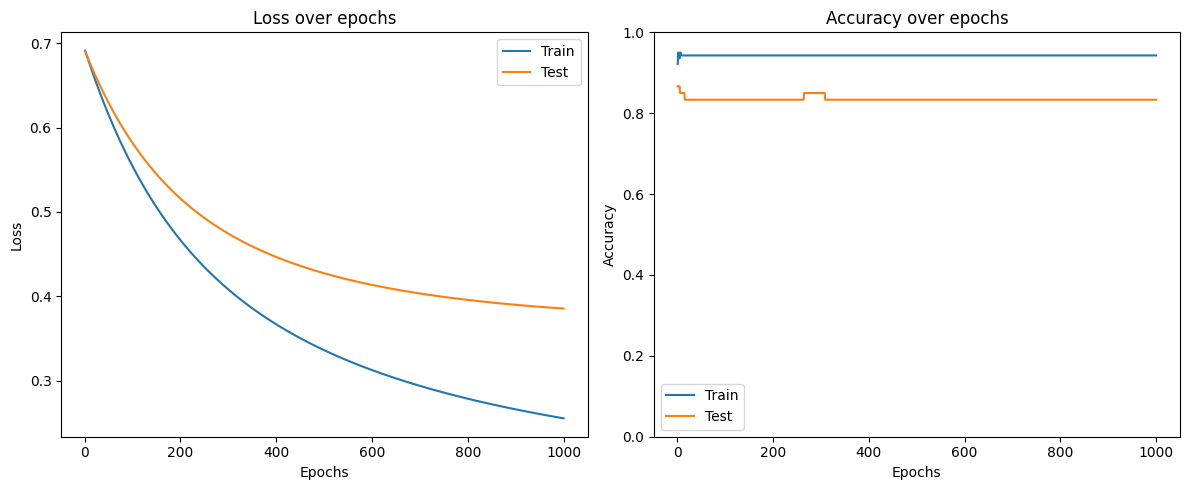

In [10]:
# Membuat hasil prediksi pada data test
y_pred_final = forward(X_test_np, weights, bias)
# Melakukan konversi hasil prediksi ke binary (0 atau 1) mengacu pada threshold (0.5)
y_pred_binary_final = (y_pred_final >= threshold).astype(int)
# Menghitung akurasi final
final_accuracy = accuracy_score(y_test_np, y_pred_binary_final)
print("Final Evaluation:")
print(f"Accuracy: {final_accuracy * 100:.2f}%")

# Evaluasi model dengan memetakan hasil prediksi pada confusion matrix
cm = confusion_matrix(y_test_np, y_pred_binary_final)
precision = precision_score(y_test_np, y_pred_binary_final)
recall = recall_score(y_test_np, y_pred_binary_final)
print('Confusion Matrix:')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Confusion Matrix Heatmap')
plt.show()

# Melakukan pemetaan nilai loss dan akurasi pada setiap epoch
plt.figure(figsize=(12, 5))
# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Train')
plt.plot(range(1, num_epochs + 1), test_losses, label='Test')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Train')
plt.plot(range(1, num_epochs + 1), test_accuracies, label='Test')

plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

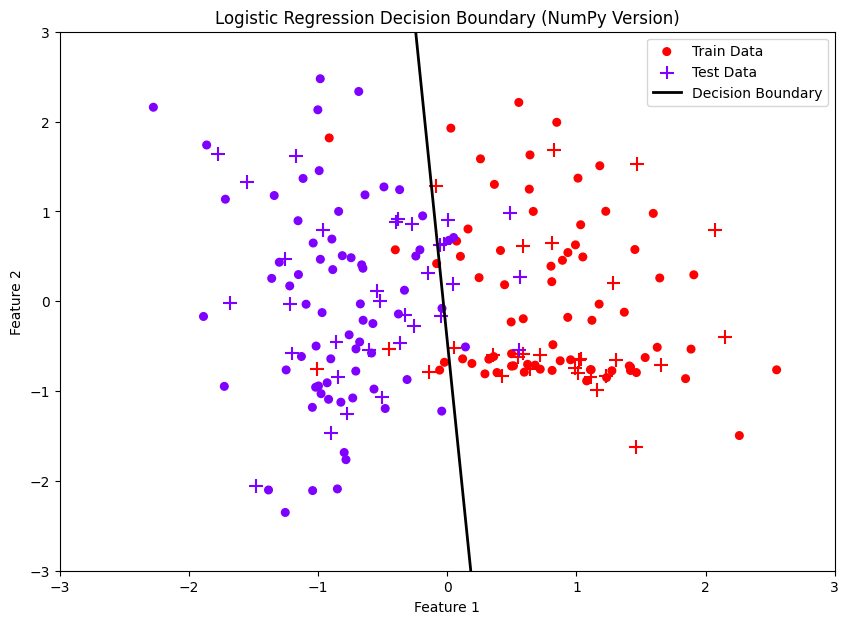

In [12]:
# Membuat fungsi visualisasi dengan decision boundary manual
def show_logistic_regression_decision_boundary(X_train, X_test, y_train, y_test, weights, bias):
  # Mengambil bobot untuk Feature 1 (w0) dan Feature 2 (w1)
  w0 = weights[0, 0]
  w1 = weights[1, 0]
  b = bias[0, 0]
  # Menghitung slope (m) dan intercept (c) -> w0*x + w1*y + b = 0
  # y = -(w0/w1)x - (b/w1)
  m = -(w0 / w1)
  c = -(b / w1)
  # Menghasilkan nilai x untuk garis
  x_line = np.linspace(X_train[:, 0].min(), X_train[:, 0].max(), 100)
  y_line = m * x_line + c
  # Plot data asli
  plt.figure(figsize=(10, 7))
  plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=30, cmap='rainbow', label='Train Data')
  plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker='+', s=100, cmap='rainbow', label='Test Data')
  # Plot decision boundary line
  plt.plot(x_line, y_line, c='black', linewidth=2, label='Decision Boundary')
  plt.title("Logistic Regression Decision Boundary (NumPy Version)")
  plt.xlabel("Feature 1")
  plt.ylabel("Feature 2")
  plt.legend()
  plt.xlim(-3, 3)
  plt.ylim(-3, 3)
  plt.show()
  # Memanggil fungsi visualisasi
show_logistic_regression_decision_boundary(X_train_np, X_test_np, y_train, y_test, weights, bias)

#1.6 Implementasi Scikit learn pada Logistic Regression

In [13]:
log_reg = LogisticRegression(solver='newton-cg', max_iter=400)
log_reg.fit(X_train_np, y_train_np)

print(log_reg.intercept_, log_reg.coef_)

log_reg.score(X_train_np, y_train_np)

[0.2599139] [[3.6284182  0.28842074]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.9428571428571428

#2 Model Improvement with L2 Regularization
#2.1 Model Definition
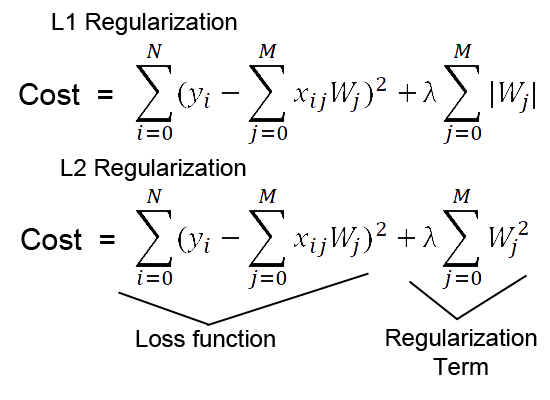
### Proses pelatihan dengan fokus perubahan nilai bobot tentunya sangat dipengarui oleh Regularized Cost Function.
### Deklarasi fungsi hyperparameter, forward bias dan l2_regularisation, yaitu dengan menambahkan parameter L2_REG yaitu produk dari lambda dengan jumlah weight yang dikuadratkan


In [24]:
class LogisticRegressionNumpy:
  def __init__(self, input_size, reg_strength=0.01):
    # Inisialisasi bobot (W) dan bias (b) secara random kecil
    self.W = np.random.randn(input_size, 1) * 0.01
    self.b = 0.0
    self.reg_strength = reg_strength # lambda
  def sigmoid(self, z):
    # np.clip digunakan untuk melakukan normalisasi yang mana ketika ada suatu
    # nilai dalam variabel z yang kurang dari -500 maka akan distandarkan menjadi -500
    # dan ketika terdapat nilai yang lebih dari 500 maka akan distandarkan menjadi 500
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
  def forward(self, x):
    # Menghitung output: sigmoid(XW + b)
    z = np.dot(x, self.W) + self.b
    return self.sigmoid(z)
  def l2_regularization(self):
    # Sesuai rumus: lambda * sum(W^2)
    return self.reg_strength * np.sum(np.square(self.W))

    # "Criterion" (Fungsi Loss) didefinisikan secara manual
  def binary_cross_entropy(self,y_true, y_pred):
    # Menghindari log(0) dengan clipping
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
  def train_step(self, X, y, lr):
    n_samples = X.shape[0]
    # 1. Forward Pass
    y_pred = self.forward(X)
    # 2. Hitung Gradien (Turunan Loss + Turunan L2)
    # Gradien Loss: (1/n) * X.T * (y_pred - y)
    # Gradien L2: (1/n) * reg_strength * W
    dz = y_pred - y
    dw = (1 / n_samples) * (np.dot(X.T, dz) + (self.reg_strength * self.W))
    db = (1 / n_samples) * np.sum(dz)
    self.W -= lr * dw
    self.b -= lr * db
    # 3. Hitung Total Cost untuk monitoring
    loss = self.binary_cross_entropy(y, y_pred)
    total_cost = loss + ((1 / n_samples * 2) * self.l2_regularization())
    return total_cost

#2.2 Training Process

### Menyiapkan Arsitektur
### Inisiasi Model
### Melakukan training seperti sebelumnya namun menambahkan reg_strength pada loss function

In [29]:
# Menyiapkan arsitektur
input_size = X_train.shape[1]
reg_strength = 0.01
learning_rate = 0.01
# Inisialisasi model
model = LogisticRegressionNumpy(input_size, reg_strength)
# Pendefinisian beberapa variabel untuk training loop
train_losses, test_losses, train_accuracies, test_accuracies = [], [], [], []
num_epochs = 1000
threshold = 0.5 # Ambang batas konversi ke binary
# Data pada Numpy tidak memerlukan target device (langsung menggunakan X_train, y_train)
# Pastikan y_train dan y_test dalam bentuk kolom (n, 1)
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)
for epoch in range(num_epochs):
  # Forward pass & Update parameter (Backpropagation manual)
  # Fungsi ini mengembalikan total_loss (BCE + L2)
  loss_val = model.train_step(X_train, y_train, lr=learning_rate)
  # Prediksi untuk hitung akurasi training
  y_train_pred = model.forward(X_train)
  y_train_binary = (y_train_pred >= threshold).astype(int)
  train_accuracy = accuracy_score(y_train, y_train_binary)
  # FASE EVALUASI - dengan keterlibatan testing data dengan perhitungan loss (BCE)
  y_test_pred = model.forward(X_test)
  test_loss = model.binary_cross_entropy(y_test, y_test_pred)
  # Konversi hasil test ke binary & hitung akurasi
  y_test_binary = (y_test_pred >= threshold).astype(int)
  test_accuracy = accuracy_score(y_test, y_test_binary)
  # Memberikan informasi pembaharuan setiap 10 epoch
  if (epoch + 1) % 10 == 0:
    print("Epoch [{}] -> Train Loss: {:.4f}; Test Loss: {:.4f}; Train Acc: {:.2f}%; Test Acc: {:.2f}%".format(epoch + 1, loss_val, test_loss, train_accuracy * 100, test_accuracy * 100))
  # Store losses and accuracies
  train_losses.append(loss_val)
  test_losses.append(test_loss)

Epoch [10] -> Train Loss: 0.6719; Test Loss: 0.6743; Train Acc: 94.29%; Test Acc: 85.00%
Epoch [20] -> Train Loss: 0.6557; Test Loss: 0.6614; Train Acc: 94.29%; Test Acc: 85.00%
Epoch [30] -> Train Loss: 0.6404; Test Loss: 0.6492; Train Acc: 94.29%; Test Acc: 83.33%
Epoch [40] -> Train Loss: 0.6258; Test Loss: 0.6376; Train Acc: 94.29%; Test Acc: 83.33%
Epoch [50] -> Train Loss: 0.6119; Test Loss: 0.6266; Train Acc: 94.29%; Test Acc: 83.33%
Epoch [60] -> Train Loss: 0.5986; Test Loss: 0.6162; Train Acc: 94.29%; Test Acc: 83.33%
Epoch [70] -> Train Loss: 0.5860; Test Loss: 0.6063; Train Acc: 94.29%; Test Acc: 83.33%
Epoch [80] -> Train Loss: 0.5740; Test Loss: 0.5969; Train Acc: 94.29%; Test Acc: 83.33%
Epoch [90] -> Train Loss: 0.5625; Test Loss: 0.5880; Train Acc: 94.29%; Test Acc: 83.33%
Epoch [100] -> Train Loss: 0.5515; Test Loss: 0.5796; Train Acc: 94.29%; Test Acc: 83.33%
Epoch [110] -> Train Loss: 0.5411; Test Loss: 0.5716; Train Acc: 94.29%; Test Acc: 83.33%
Epoch [120] -> Trai

#2.3 Model Evaluation
Melakukan Analisis performa seperti modul sebelumnya

Final Evaluation:
Accuracy: 83.33%


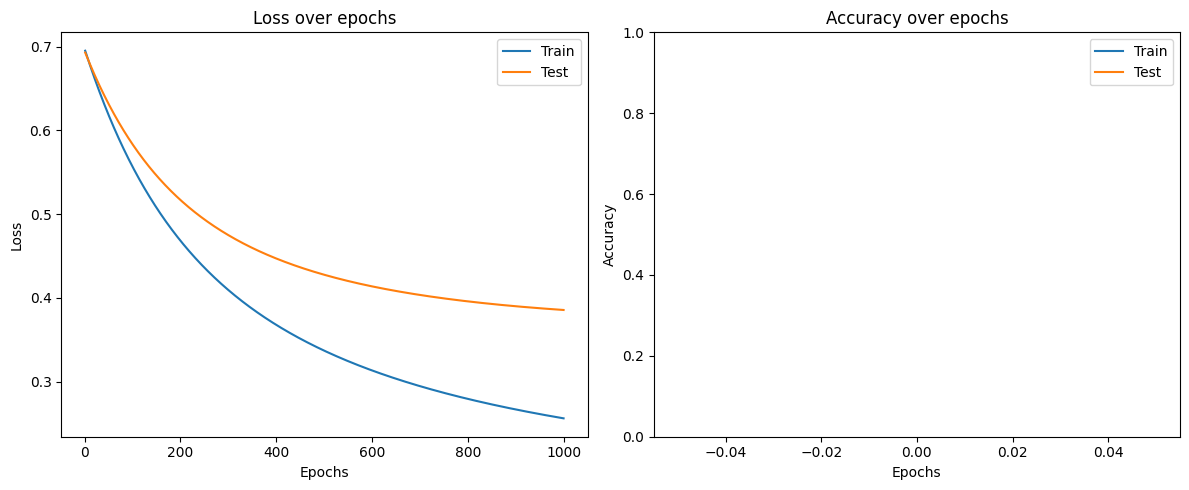

In [23]:
y_pred_final = model.forward(X_test)
# Melakukan konversi hasil prediksi ke binary (0 atau 1) mengacu pada threshold
y_pred_binary_final = (y_pred_final >= threshold).astype(int)
# Menghitung akurasi final
# Pastikan y_test dalam bentuk yang sesuai (n_samples, 1)
final_accuracy = accuracy_score(y_test, y_pred_binary_final)
print("Final Evaluation:")
print(f'Accuracy: {final_accuracy*100:.2f}%')

# Melakukan pemetaan nilai loss dan akurasi pada setiap epoch pada proses training
plt.figure(figsize=(12, 5))
# Plot Loss
plt.subplot(1, 2, 1)
# Menggunakan range(1, len(...) + 1) agar dinamis mengikuti jumlah epoch yang dijalankan
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train')
plt.plot(range(1, len(test_losses) + 1), test_losses, label='Test')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label='Train')
plt.plot(range(1, len(test_accuracies) + 1), test_accuracies, label='Test')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

#3. Case Study: Classification in Fashion MNIST (Multi-Class)
### One Hot Encoding digunakan untuk mengubah data kategorikal menjadi data binary
### **Data Fashion MNIST** merupakan data sampel Fashion berupa gambar grayscale berukuran 28x28 yang digolongkan ke dalam 10 kelas:
1. T-shirt/top
2. Trouser/pants
3. Pullover shirt
4. Dress
5. Coat
6. Sandal
7. Shirt
8. Sneaker
9. Bag
10. Ankle boot

### **Cross Entropy loss** merupakan loss yang menyerupai Entropy, Namun yang menjadi pembeda adalah dikalikan True class dengan log dari Predicted Class. Karena Entropy merupakan probabilitas yang menyebabkan suatu variable memengaruhi hasil akhir tertentu, pada logistic digunakan cross entropy loss.

### Berbeda dengan Sigmoid, **softmax** menghasilkan output berupa probabilitas dengan persamaan berikut :
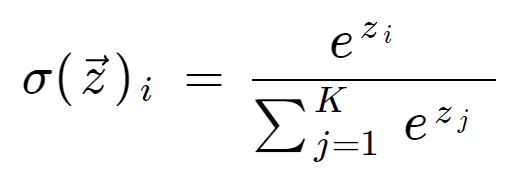

### Terakhir, Karena sifatnya digunakan 10 neuron untuk menghitung softmax



In [34]:

# Import modul utama untuk komputasi numerik dan visualisasi
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import fetch_openml
# Menggunakan keras hanya untuk mengambil data mentah Fashion MNIST sebagai array NumPy
from tensorflow.keras.datasets import fashion_mnist

# Pengaturan untuk menentukan device komputasi yang akan digunakan
device = "cpu"
print(f"Using device: {device}")

# Mengunduh dan memuat dataset (otomatis mengembalikan array NumPy)
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
# Normalisasi data (0-255 menjadi 0-1) dan konversi tipe data
train_images = train_images.astype(np.float32) / 255.0
test_images = test_images.astype(np.float32) / 255.0
# Melakukan pembagian data manual (50.000 training, 10.000 validation)
val_images = train_images[50000:]
val_labels = train_labels[50000:]
train_images = train_images[:50000]
train_labels = train_labels[:50000]



Using device: cpu


#2.1 Data Preprocessing
### seperti sebelumnya training dilakukan **per batch**
### Untuk menampilkan pada matplotlib data dibuat menjadi **matrix**
### Data kemudian dibuat menjadi batches dan diplot

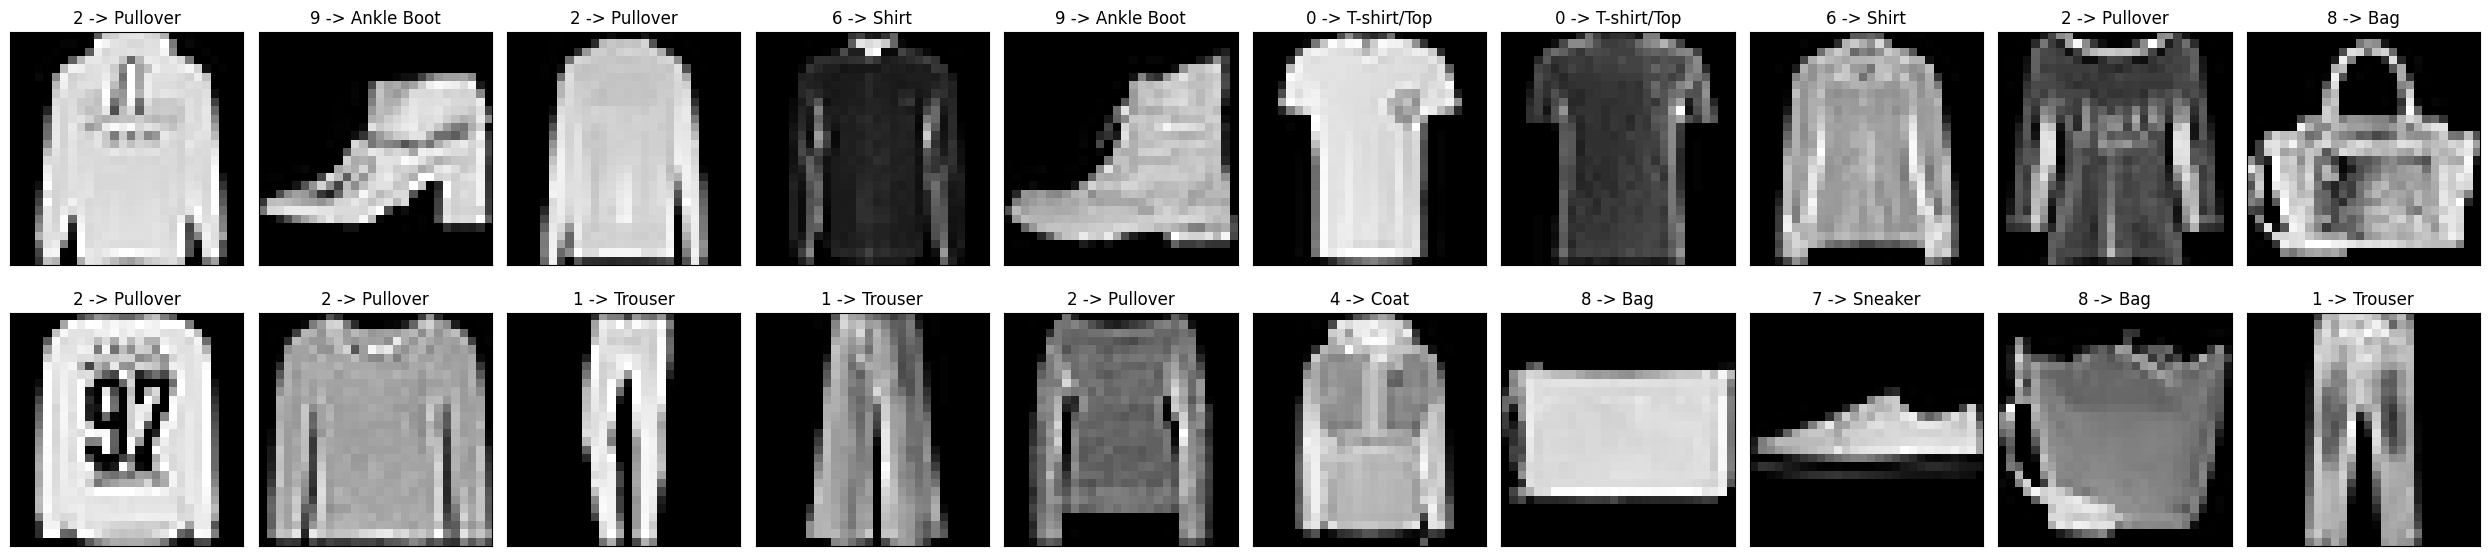

In [36]:
# Data constants
input_size = 28 * 28
num_classes = 10
# Hyperparameters
batch_size = 128
# Fungsi sederhana untuk mengambil batch
def get_batches(X, y, batch_size, shuffle=True):
  indices = np.arange(len(X))
  if shuffle:
    np.random.shuffle(indices)
    for i in range(0, len(X), batch_size):
      batch_idx = indices[i:i + batch_size]
      yield X[batch_idx], y[batch_idx]

# Pembuatan fungsi untuk melakukan konversi images agar siap ditampilkan di matplotlib
def img_convert(image):
  # Mengasumsikan input berupa array NumPy
  # Jika data masih flatten (784), kembalikan ke bentuk (28, 28)
  if image.ndim == 1:
    image = image.reshape(28, 28)
  # Jika data dalam format (C, H, W) ubah ke (H, W, C)
  if image.ndim == 3 and image.shape[0] < image.shape[1]:
    image = image.transpose(1, 2, 0)
    # Memastikan citra berada pada rentang [0, 1]
  image = np.clip(image, 0, 1)
  return image

  # Mendefinisikan label kategori
classes = ('T-shirt/Top', 'Trouser', 'Pullover', 'Dress', 'Coat',
'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')
# Mengambil satu batch pertama dari data training
data_gen = get_batches(train_images, train_labels, batch_size, shuffle=True)
images_batch, labels_batch = next(data_gen)

# Menampilkan 20 data pertama dari batch tersebut
fig = plt.figure(figsize=(25, 6))
for idx in np.arange(20):
  ax = fig.add_subplot(2, 10, idx + 1, xticks=[], yticks=[])
  # Menggunakan fungsi img_convert untuk memproses array
  plt.imshow(img_convert(images_batch[idx]), cmap='gray')
  # Mengambil nama class berdasarkan index label
  label_idx = labels_batch[idx]
  ax.set_title(f"{label_idx} -> {classes[label_idx]}")
plt.tight_layout()
plt.show()

# 3.3 Definisikan class dan method
### Untuk mempermudah analisis source code dienkapsulasi dalam class
### Pada Class didefinisikan method-method sebagai berikut :
1. Constructor, untuk membuat object model
2. Softmax, Fungsi yang menghitung operasi softmax
3. Forward, Fungsi feedforward : reshape data xb -> dilakukan dot product -> masukkan output pada activation function(softmax)
4. accuracy, mencari output dengan probabilitas tertinggi
5. training step, fungsi yang melakukan one hot encoding pada image matrix
6. validation step, fungsi yang menjalankan acurracy dan loss dari model
7. validation epoch end, mendefinisikan kualitas per epoch
8. backward step, proses back propagation pada fungsi, didapatkan dari gradient descent(dengan chain rule turunan parsial)
9. Train, Fungsi Top level

In [43]:
class FMnistModel:
  def __init__(self, input_size, num_classes):
    self.input_size = input_size
    # Inisialisasi bobot (weights) dan bias secara random
    self.W = np.random.randn(input_size, num_classes) * 0.01
    self.b = np.zeros((1, num_classes))
    self.num_classes = num_classes
  def softmax(self, z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)
  def forward(self, xb):
    # xb.reshape(-1, 784)
    xb = xb.reshape(-1, self.input_size)
    # Operasi Linear: z = xW + b
    z = np.dot(xb, self.W) + self.b
    # Aktivasi Softmax
    out = self.softmax(z)
    return out
  # Mendefinisikan function untuk menghitung akurasi dari hasil prediksi
  def accuracy(self, outputs, labels):
    # outputs: hasil prediksi (probabilitas), labels: label asli (angka 0-9)
    # Mencari indeks dengan nilai probabilitas tertinggi
    labels_pred = np.argmax(outputs, axis=1)
    # Menghitung rata-rata kecocokan antara prediksi dan label asli
    return np.mean(labels_pred == labels)
  # Mendefinisikan fungsi untuk satu langkah training (Forward Pass & Loss)
  def training_step(self, batch):
    images, labels = batch
    # 1. Menghasilkan hasil prediksi lewat forward propagation
    out = self.forward(images)
    # 2. Konversi labels ke one-hot encoding untuk hitung loss
    labels_one_hot = np.eye(self.num_classes)[labels]
    # 3. Menghitung nilai loss (Cross Entropy)
    # Menambahkan nilai kecil (1e-15) agar tidak log(0)
    loss = -np.mean(np.sum(labels_one_hot * np.log(out + 1e-15), axis=1))
    return loss
  # Mendefinisikan fungsi untuk melakukan validasi
  def validation_step(self, batch):
    images, labels = batch
    # 1. Menghasilkan hasil prediksi model
    out = self.forward(images)
    # 2. Hitung Loss
    labels_one_hot = np.eye(self.num_classes)[labels]
    loss = -np.mean(np.sum(labels_one_hot * np.log(out + 1e-15), axis=1))
    # 3. Hitung Akurasi
    acc = self.accuracy(out, labels)
    return {'val_loss': loss, 'val_acc': acc}
  # Mendefinisikan fungsi untuk menghitung rata-rata loss dan accuracy per epoch
  def validation_epoch_end(self, outputs):
    batch_losses = [x['val_loss'] for x in outputs]
    epoch_loss = np.mean(batch_losses)
    batch_accs = [x['val_acc'] for x in outputs]
    epoch_acc = np.mean(batch_accs)
    return {'val_loss': epoch_loss, 'val_acc': epoch_acc}
  # Menampilkan kualitas model pada setiap epoch
  def epoch_end(self, epoch, result):
    print("Epoch [{}], val_loss: {:.4f}, val_acc: {:.4f}".format(epoch, result['val_loss'], result['val_acc']))
  # Tambahkan fungsi update ke model yang tadi
  def update_parameters(self, grads, lr):
    # Mengupdate W dan b menggunakan Stochastic Gradient Descent (SGD)
    self.W -= lr * grads['dW']
    self.b -= lr * grads['db']
  def backward_step(self, xb, yb, out):
    # xb: input, yb: label asli (one-hot), out: hasil softmax
    m = xb.shape[0]
    # Menghitung selisih prediksi dan label
    dz = out - yb
    # Menghitung gradient untuk W dan b
    dW = (1/m) * np.dot(xb.reshape(m, -1).T, dz)
    db = (1/m) * np.sum(dz, axis=0, keepdims=True)
    return {'dW': dW, 'db': db}
  # Proses training dengan memperhatikan epoch dan batch
  def train(self, train_images, train_labels, val_images, val_labels, epochs, batch_size, lr):
    for epoch in range(epochs):
      # Blok Tahapan Training
      # Melakukan iterasi manual per batch
      for i in range(0, len(train_images), batch_size):
        # Ambil potongan batch
        xb = train_images[i:i+batch_size]
        yb_raw = train_labels[i:i+batch_size]
        # Konversi yb ke one-hot untuk keperluan hitung gradient
        yb = np.eye(self.num_classes)[yb_raw]
        # 1. Forward Pass
        out = self.forward(xb)
        # 2. Backward Pass (Hitung Gradient)
        grads = self.backward_step(xb, yb, out)
        # 3. Update Parameters
        self.update_parameters(grads, lr)
        # Blok Tahapan Validation
        # gunakan seluruh data val_images untuk evaluasi di akhir epoch model
        val_out = self.forward(val_images)
      result = self.validation_step((val_images, val_labels))
      # Cetak hasil
      self.epoch_end(epoch, result)
      history.append(result)

In [ ]:
# 3.4 Training
### memanggil top level method dan menjalankan plotting benchmark

Epoch [0], val_loss: 0.5655, val_acc: 0.8105
Epoch [1], val_loss: 0.5171, val_acc: 0.8253
Epoch [2], val_loss: 0.4943, val_acc: 0.8312
Epoch [3], val_loss: 0.4803, val_acc: 0.8350
Epoch [4], val_loss: 0.4705, val_acc: 0.8378
Epoch [5], val_loss: 0.4632, val_acc: 0.8397
Epoch [6], val_loss: 0.4575, val_acc: 0.8410
Epoch [7], val_loss: 0.4529, val_acc: 0.8436
Epoch [8], val_loss: 0.4491, val_acc: 0.8455
Epoch [9], val_loss: 0.4460, val_acc: 0.8462


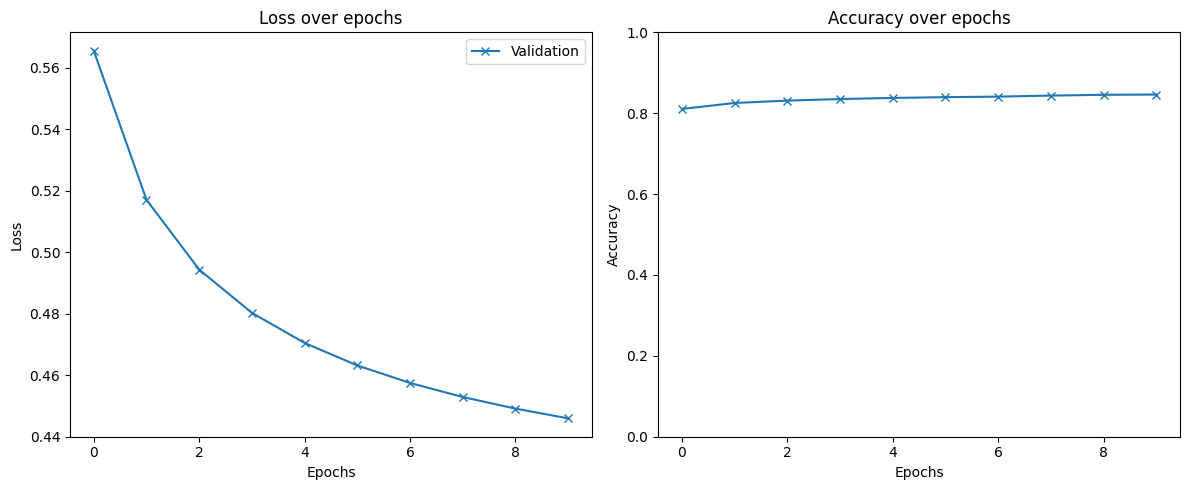

In [44]:
# Inisialisasi beberapa hal untuk kebutuhan proses training
model = FMnistModel(input_size, num_classes)
epochs = 10
lr = 0.1
history = []
model.train(train_images, train_labels,
            val_images, val_labels,
            epochs, batch_size, lr)
# Melakukan plot kualitas model (loss dan accuracy) vs training epochs
plt.figure(figsize=(12, 5))
# Plot Loss
plt.subplot(1, 2, 1)
loss = [r['val_loss'] for r in history]
plt.plot(loss, '-x')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Validation'])
# Plot Accuracy
plt.subplot(1, 2, 2)
accuracies = [r['val_acc'] for r in history]
plt.plot(accuracies, '-x')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# 3.5 Evaluasi model pada test set

Testing Result
Test_Loss: 0.4689 
Test_Acc: 0.8368
Hasil Probabilitas per Kelas:
T-shirt/Top  - 0.000009
Trouser      - 0.000004
Pullover     - 0.000045
Dress        - 0.000018
Coat         - 0.000061
Sandal       - 0.149228
Shirt        - 0.000115
Sneaker      - 0.213669
Bag          - 0.008514
Ankle Boot   - 0.628337

Jumlah semua nilai probabilitas kelas: 1.0


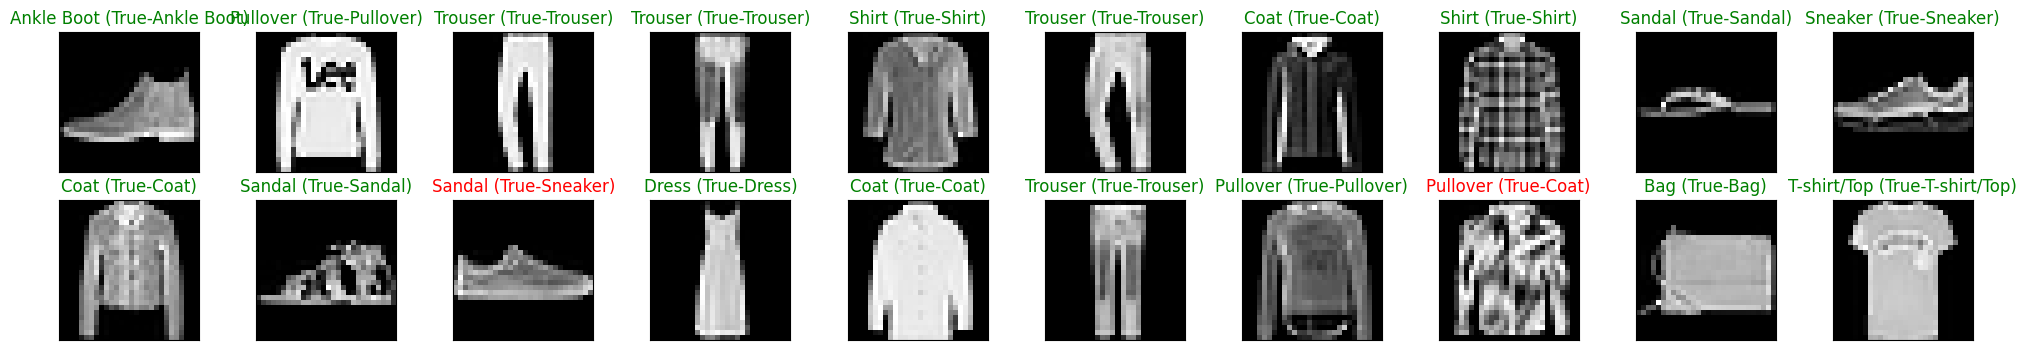

In [45]:
# Evaluasi model pada test set

# 1. Forward pass untuk semua data test
test_out = model.forward(test_images)

# 2. Hitung Loss (Cross Entropy)
test_labels_one_hot = np.eye(model.num_classes)[test_labels]
test_loss = -np.mean(np.sum(test_labels_one_hot * np.log(test_out + 1e-15), axis=1))

# 3. Hitung Akurasi menggunakan method dari class
test_acc = model.accuracy(test_out, test_labels)

print("Testing Result\nTest_Loss: {:.4f} \nTest_Acc: {:.4f}".format(test_loss, test_acc))

classes = ('T-shirt/Top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')

# Mengambil 20 data test pertama
images = test_images[:20]
labels = test_labels[:20]

# Melakukan prediksi
output = model.forward(images)
preds = np.argmax(output, axis=1)

fig = plt.figure(figsize=(25, 4))

for idx in np.arange(20):

    ax = fig.add_subplot(2, 10, idx+1, xticks=[], yticks=[])

    plt.imshow(img_convert(images[idx]), cmap='gray')

    # Judul berwarna hijau jika benar, merah jika salah
    color = "green" if preds[idx] == labels[idx] else "red"

    ax.set_title("{} (True-{})".format(classes[preds[idx]], classes[labels[idx]]),
                 color=color)

# Nilai output[0] adalah probabilitas untuk gambar pertama
softmax_outputs = output[0]

print("Hasil Probabilitas per Kelas:")

for i, prob in enumerate(softmax_outputs):
    print(f"{classes[i]:12} - {prob:.6f}")

print(f"\nJumlah semua nilai probabilitas kelas: {np.sum(softmax_outputs):.1f}")